In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Avaliando as variáveis previamente selecionadas no notebook 1

In [2]:
df = pd.read_csv('../data/df_filtered.csv')

In [ ]:
df.head

,id,safra,y,VAR_6,VAR_20,VAR_19,VAR_25,VAR_44,VAR_12,VAR_9,VAR_69,VAR_77,VAR_57,VAR_33,VAR_59,VAR_53
0,1,201404,0,3277.0,8,45.0,12.0,11.0,299.0,500.00,156.38,0.00,45,18.0,95.54,3380.00
1,2,201407,0,2443.0,12,18.0,9.0,9.0,224.0,1000.00,707.84,54.00,60,13.0,97.73,1000.00
2,3,201405,0,1824.0,12,2.0,3.0,12.0,106.0,1893.35,471.86,121.98,31,2.0,294.57,1893.35
3,4,201412,0,3796.0,12,11.0,0.0,6.0,NaN,3000.00,119.96,0.00,76,3.0,NaN,3000.00
4,5,201403,1,437.0,12,0.0,0.0,0.0,NaN,2000.00,NaN,NaN,38,0.0,NaN,2946.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10733,10734,201406,0,515.0,10,0.0,0.0,0.0,NaN,500.00,NaN,NaN,27,0.0,NaN,500.00
10734,10735,201407,0,1029.0,12,0.0,0.0,10.0,91.0,1724.65,203.07,61.11,40,0.0,29.01,5524.65
10735,10736,201403,1,819.0,12,0.0,0.0,3.0,NaN,2759.03,260.00,0.00,45,0.0,369.46,3759.03
10736,10737,201402,1,1740.0,12,6.0,8.0,8.0,379.0,1000.00,447.77,92.91,28,2.0,319.33,2000.00


In [7]:
variaveis = df.columns[3:]

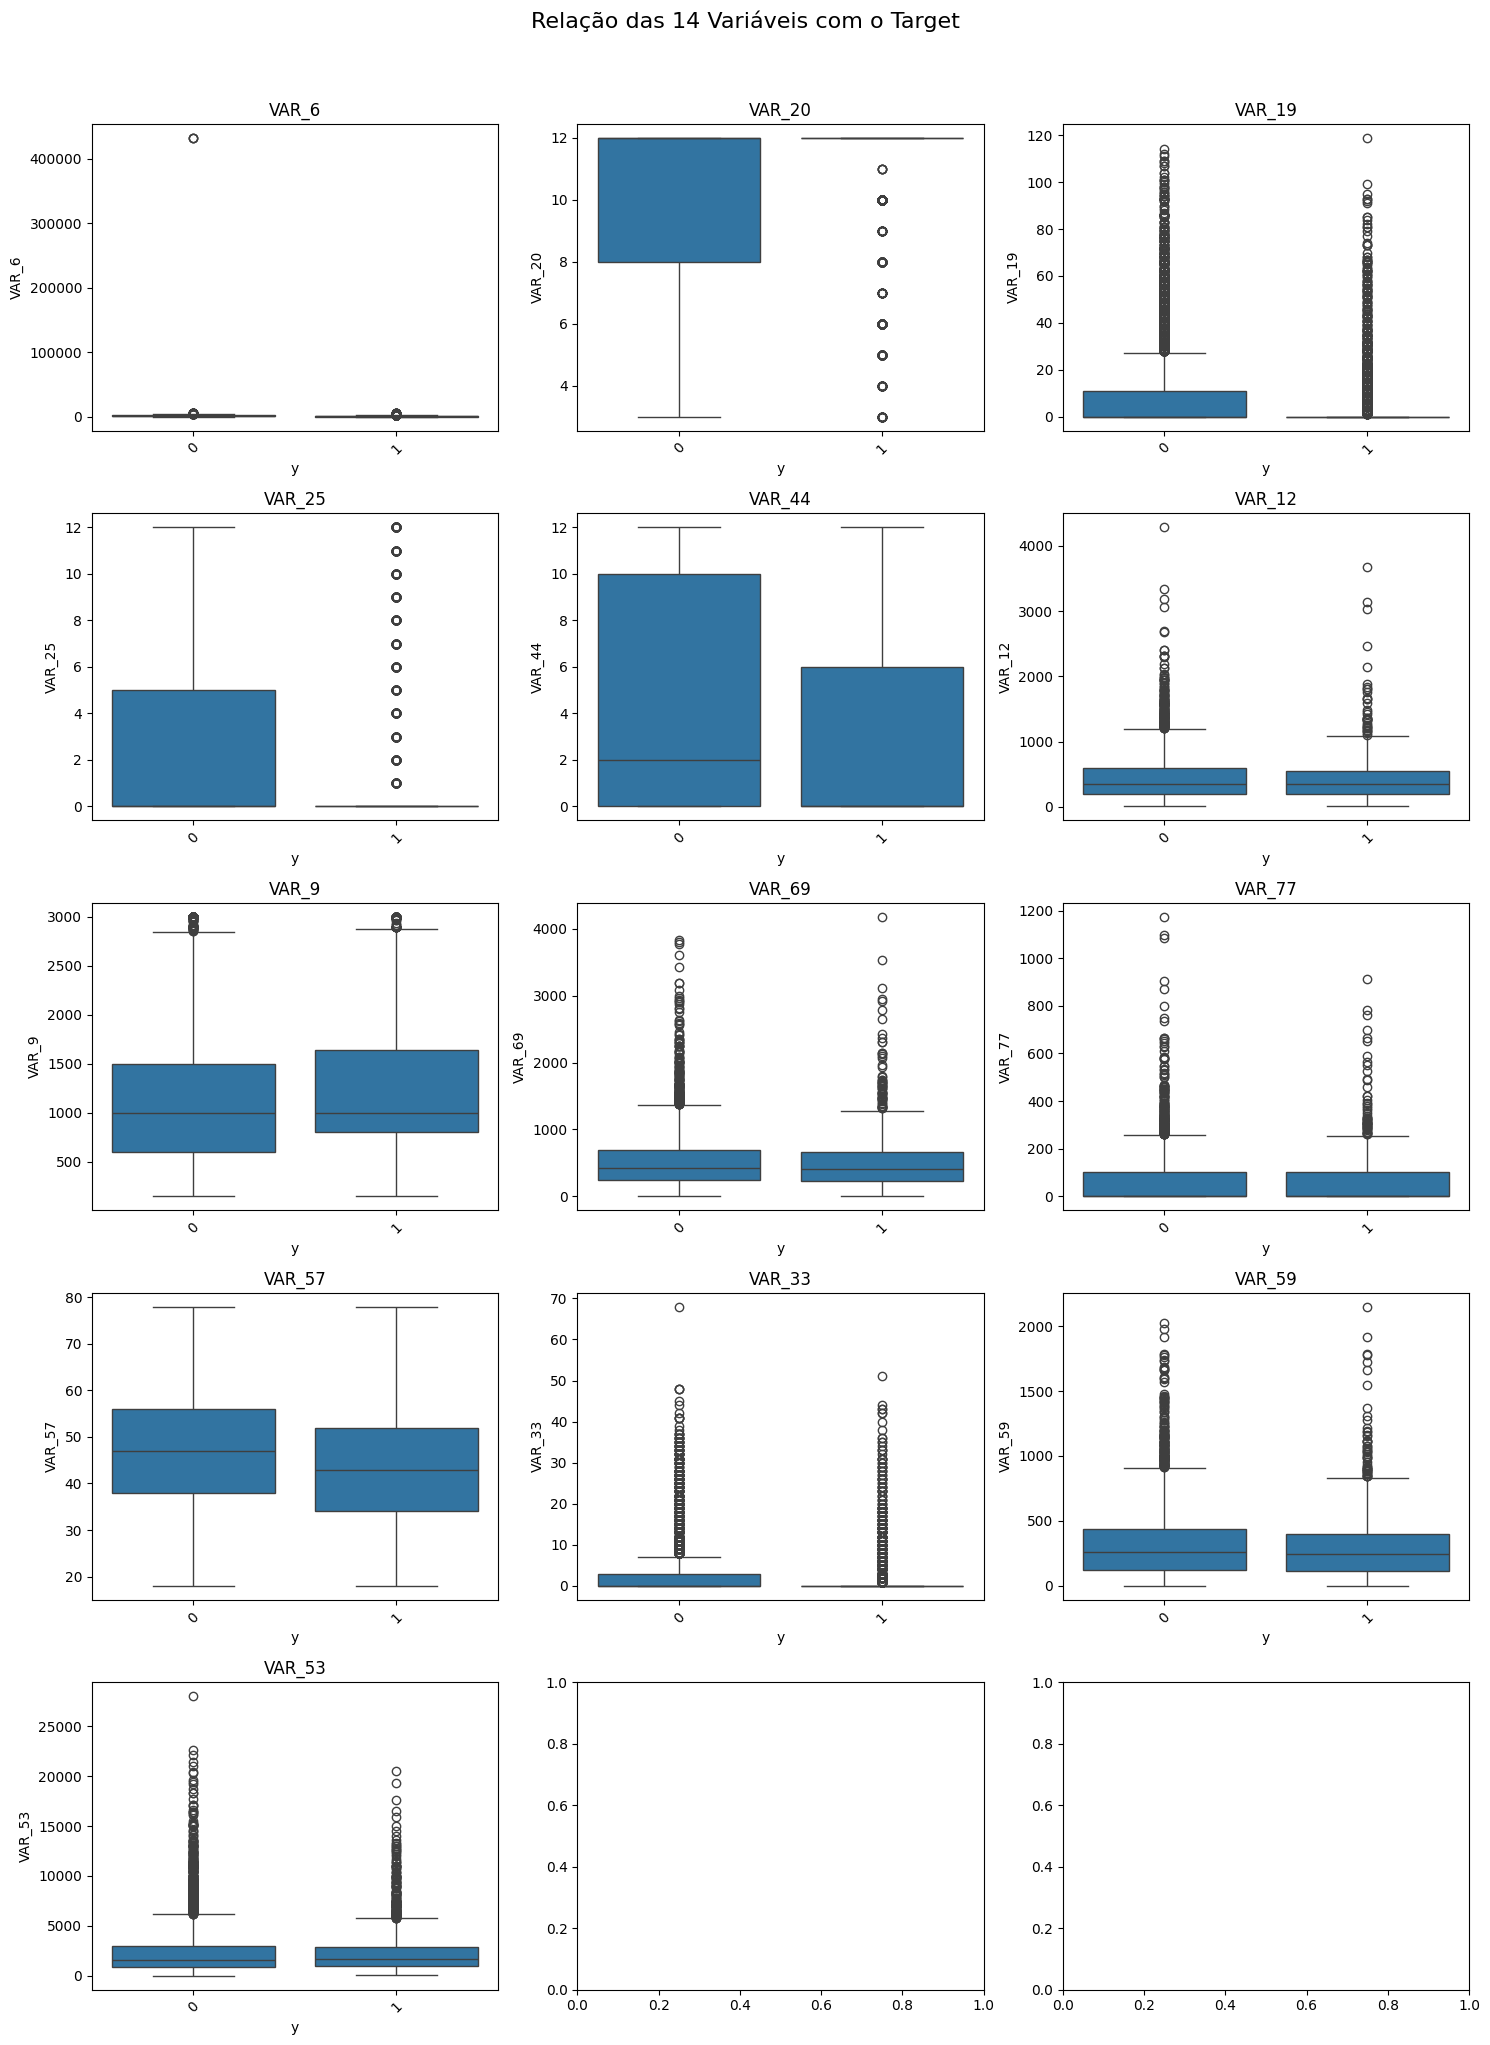

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
fig.suptitle('Relação das 14 Variáveis com o Target', fontsize=16, y=1.02)

for idx, var in enumerate(variaveis):
    row, col = divmod(idx, 3)
    ax = axes[row, col]
    
    # Para numéricas: boxplot por target
    if df[var].dtype in ['float64', 'int64']:
        sns.boxplot(x='y', y=var, data=df, ax=ax)
    # Para categóricas: barplot
    else:
        pd.crosstab(df[var], df['y'], normalize='index').plot(
            kind='bar', ax=ax, stacked=True
        )
    
    ax.set_title(f'{var}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('14_vars_vs_target.png', dpi=300, bbox_inches='tight')

Fazemos mais uma análise do comportamento da taxa de resposta da variável target com relação às variáveis explicativas.

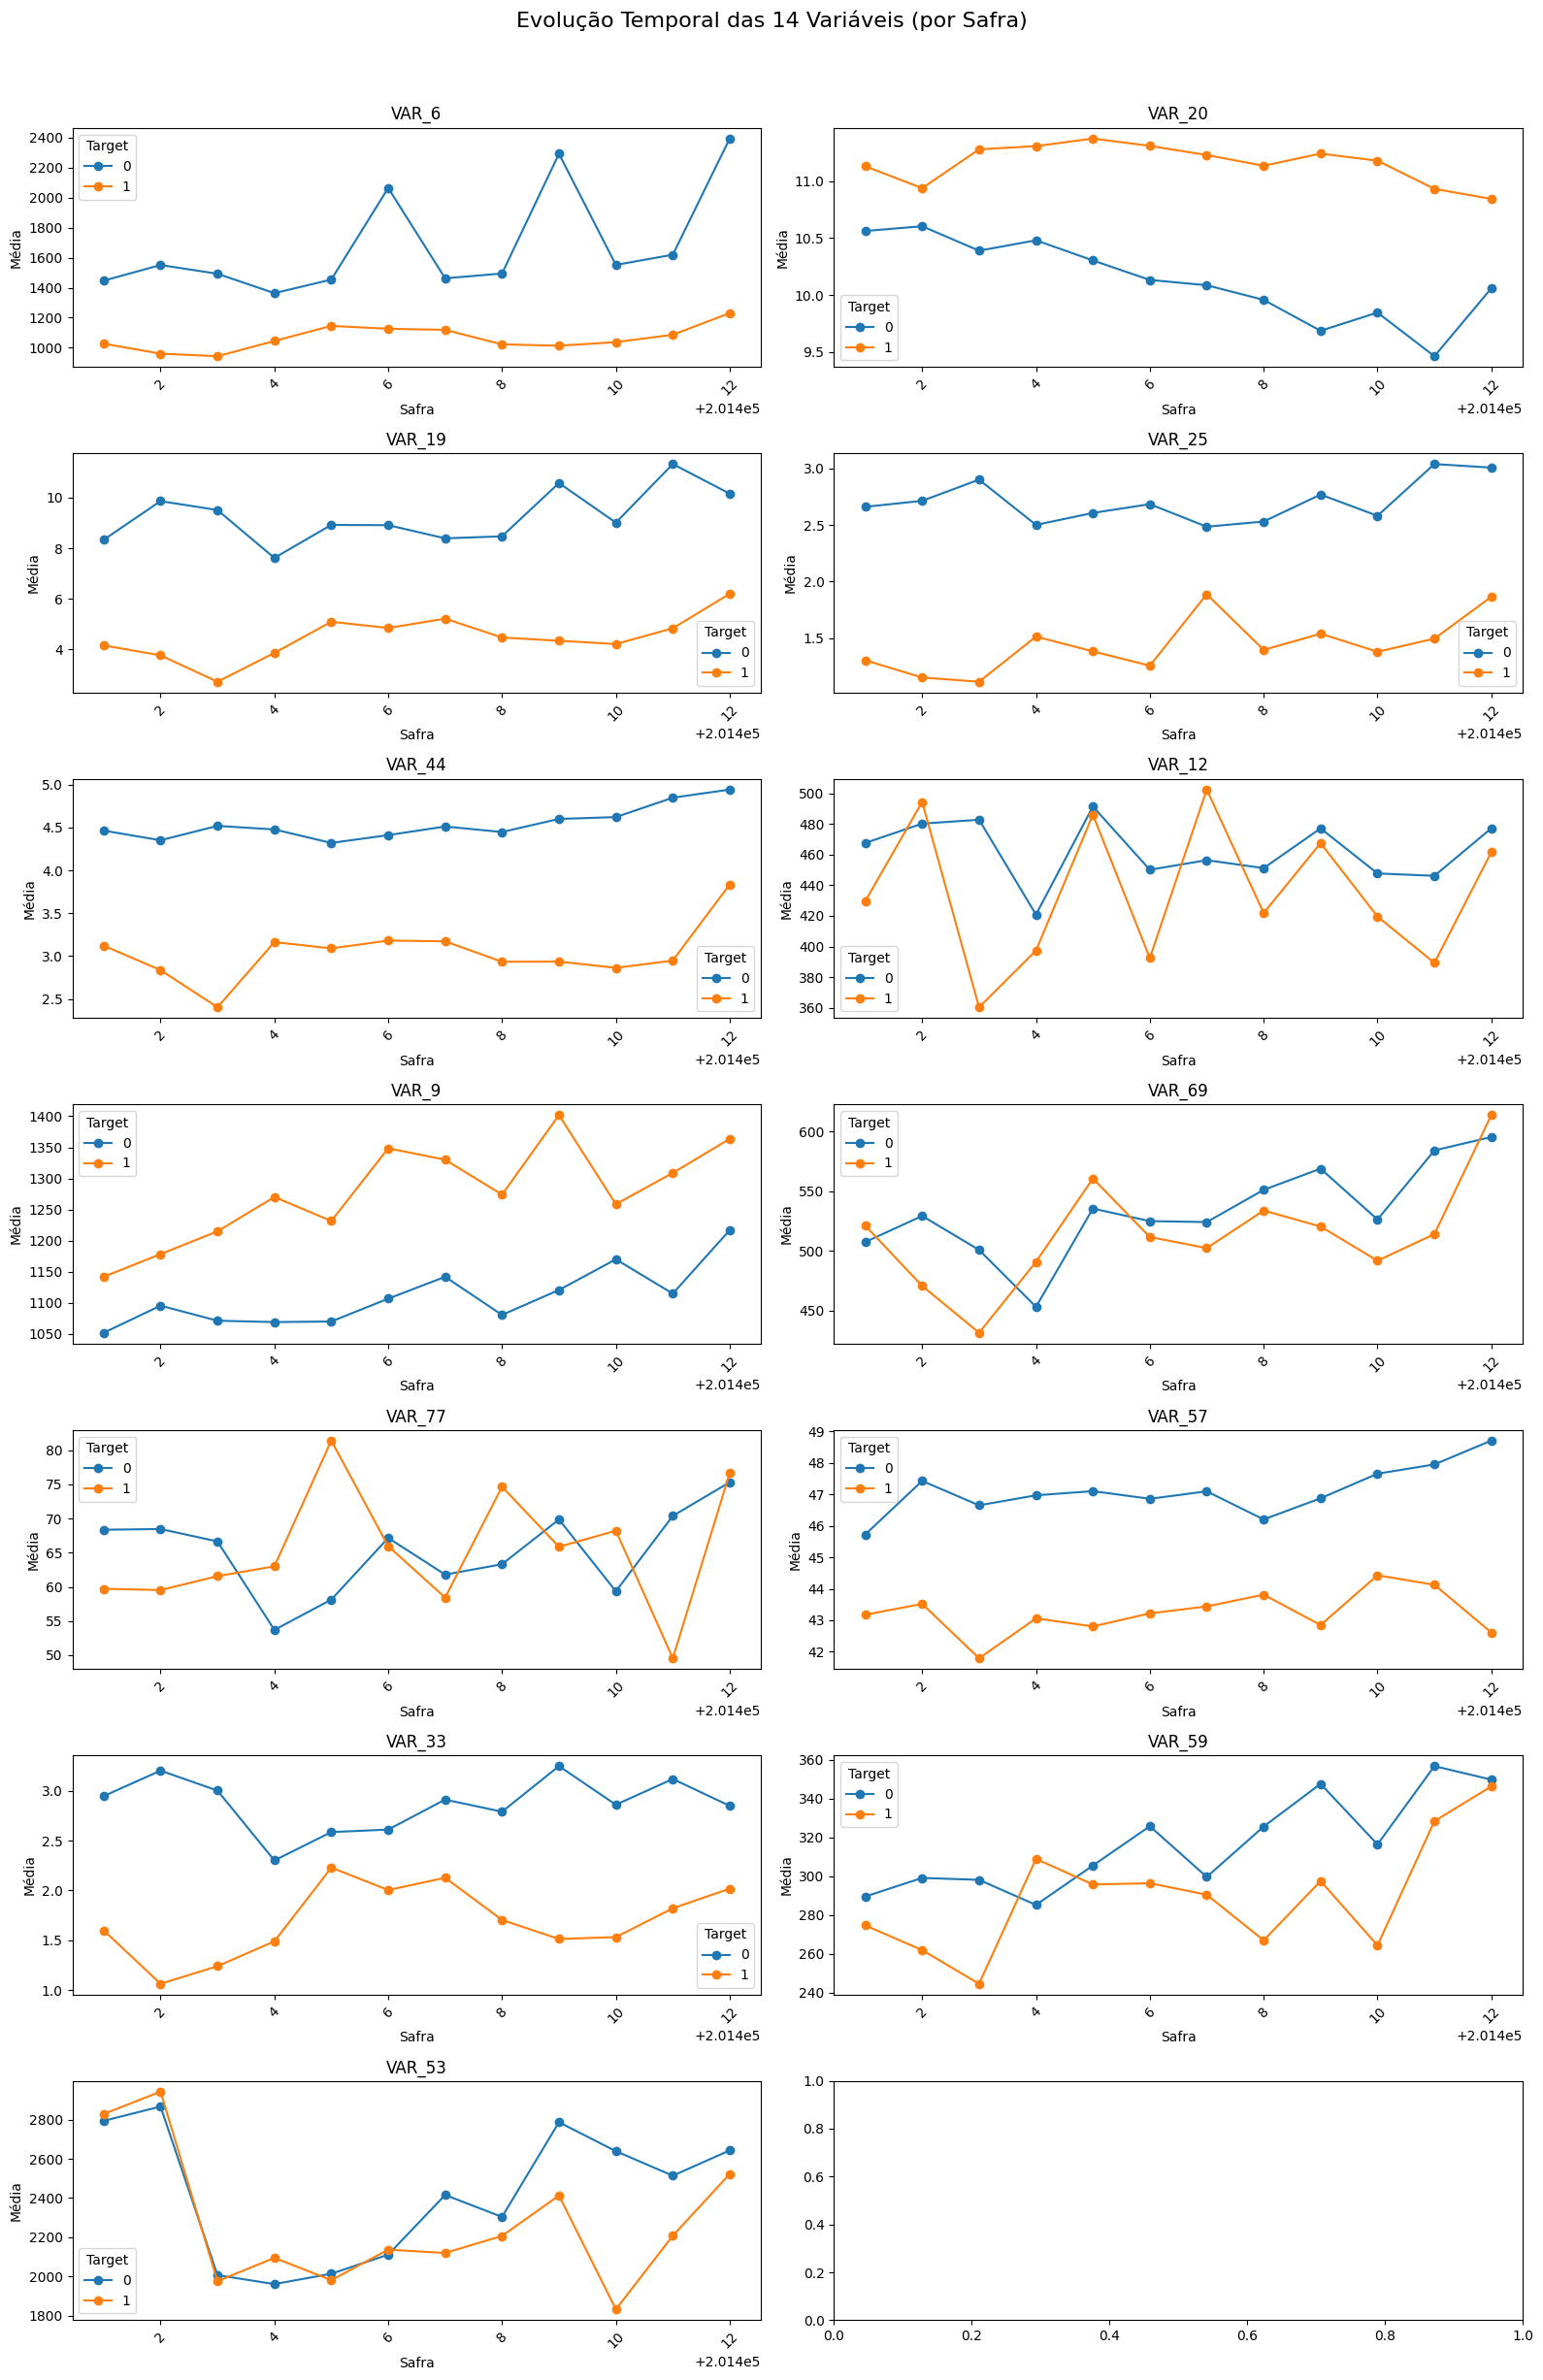

In [13]:
# Análise: Como cada variável se comporta ao longo das safras?
fig, axes = plt.subplots(7, 2, figsize=(16, 24))
fig.suptitle('Evolução Temporal das 14 Variáveis (por Safra)', fontsize=16, y=1.02)

for idx, var in enumerate(variaveis):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    # Calcular média da variável por safra e target
    temporal_analysis = df.groupby(['safra', 'y'])[var].mean().unstack()
    
    temporal_analysis.plot(ax=ax, marker='o')
    ax.set_title(f'{var}')
    ax.set_xlabel('Safra')
    ax.set_ylabel('Média')
    ax.legend(title='Target')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

É interessante notar que algumas das variáveis possuem comportamento estável entre as safras, enquanto outras variáveis (como 53, 59 e 12) em que os perfis se cruzam apresentam comportamento instável. O Alto % de missing dessas variáveis justifica o comportamento disitinto entre as variáveis.

In [14]:
missing_14 = df[variaveis].isnull().sum()
missing_pct_14 = (missing_14 / len(df)) * 100

print("Missing Values nas 14 variáveis:")
print(pd.DataFrame({
    'Missing_Count': missing_14,
    'Missing_Pct': missing_pct_14
}).sort_values('Missing_Pct', ascending=False))

Missing Values nas 14 variáveis:
        Missing_Count  Missing_Pct
VAR_12           7197    67.023654
VAR_69           5565    51.825293
VAR_77           5565    51.825293
VAR_59           4551    42.382194
VAR_53           1759    16.381077
VAR_6              91     0.847458
VAR_44             61     0.568076
VAR_25             61     0.568076
VAR_19             61     0.568076
VAR_33             61     0.568076
VAR_20              0     0.000000
VAR_9               0     0.000000
VAR_57              0     0.000000


Filtramos essa variável para modelagem final e geramos o dataset para modelagem.

In [30]:
selected_vars = missing_pct_14.loc[missing_pct_14<1.0].index.to_list()

In [35]:
df_final = df[['id', 'safra', 'y'] + selected_vars]

In [38]:
df_final.to_csv('../data/df_final.csv', header=True, index=False)